Re-run the notebook to see visualizations as some were done with plotly. Rerun time about 20-30 secs

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from helper import *

In [2]:
path = "Data/GasElectricity Consumption.xlsx"
path_pv = "Data/PV generation.csv"

In [3]:
df = ETL_single(path,
           column_names=['Date', 'elecmeter', 'gasmeter'],
           date_column='Date',
           make_date_index=True,
           header=2,
           date_format="%d.%m.%Y %H:%M",
           column_format=[np.float32,np.float32]
)

DataFrame Description and initial cleaning report:
---------------------------------------
Shape: (35137, 2)
Duplicated Timestamps: 4
Date
2024-10-27 02:00:00    2
2024-10-27 02:15:00    2
2024-10-27 02:30:00    2
2024-10-27 02:45:00    2
Name: count, dtype: int64
After removing duplicates, new shape: (35133, 2)
Index is already sorted.
Number of frequency of Dates: 2
Date
0 days 00:15:00    35131
0 days 01:15:00        1
Name: count, dtype: int64
Frequency variation point report:
---------------------------------------
From 2024-01-01 00:00:00 to 2024-03-31 01:45:00, frequency is 0 days 00:15:00, and count is 8648
From 2024-03-31 01:45:00 to 2024-03-31 03:00:00, frequency is 0 days 01:15:00, and count is 2
From 2024-03-31 03:00:00 to 2025-01-01 00:00:00, frequency is 0 days 00:15:00, and count is 26485
elecmeter dtype before: float64
elecmeter dtype after: float32
Number of null values for elecmeter is 0
gasmeter dtype before: float64
gasmeter dtype after: float32
Number of null value

In [4]:
df_pv = ETL_single(path_pv,
           column_names=['Zeit', 'Wert', 'originalwert'],
           date_column='Zeit',
           make_date_index=True,
           header=1,
           date_format="%d.%m.%Y %H:%M",
           column_format = [np.float32,np.float32]
)

DataFrame Description and initial cleaning report:
---------------------------------------
Shape: (35137, 2)
Duplicated Timestamps: 4
Zeit
2024-10-27 02:00:00    2
2024-10-27 02:15:00    2
2024-10-27 02:30:00    2
2024-10-27 02:45:00    2
Name: count, dtype: int64
After removing duplicates, new shape: (35133, 2)
Index is already sorted.
Number of frequency of Dates: 2
Zeit
0 days 00:15:00    35131
0 days 01:15:00        1
Name: count, dtype: int64
Frequency variation point report:
---------------------------------------
From 2024-01-01 00:00:00 to 2024-03-31 01:45:00, frequency is 0 days 00:15:00, and count is 8648
From 2024-03-31 01:45:00 to 2024-03-31 03:00:00, frequency is 0 days 01:15:00, and count is 2
From 2024-03-31 03:00:00 to 2025-01-01 00:00:00, frequency is 0 days 00:15:00, and count is 26485
Wert dtype before: float64
Wert dtype after: float32
Number of null values for Wert is 0
originalwert dtype before: float64
originalwert dtype after: float32
Number of null values for o

**Adjust Freqency**

In [5]:
df.index.inferred_freq

In [6]:
df.index = pd.to_datetime(df.index)
index = pd.date_range(start=df.index[0], end=df.index[-2], freq='15min')
df_year = df.reindex(index).interpolate(method='time')
df_year.tail()

,elecmeter,gasmeter
2024-12-31 22:45:00,9.883936,72.000000
2024-12-31 23:00:00,12.289136,104.000000
2024-12-31 23:15:00,13.470864,88.000000
2024-12-31 23:30:00,12.372524,76.000000
2024-12-31 23:45:00,12.787476,83.839996


In [7]:
df_year.index.inferred_freq

'15min'

In [8]:
df_hour = df_year.resample('h').mean()

df_hour.tail()

,elecmeter,gasmeter
2024-12-31 19:00:00,12.194115,110.029999
2024-12-31 20:00:00,11.726492,110.070000
2024-12-31 21:00:00,12.120000,117.930000
2024-12-31 22:00:00,11.380377,82.040001
2024-12-31 23:00:00,12.730000,87.959999


In [9]:
df_hour.index.inferred_freq

'h'

In [10]:
df_pv = df_pv[["Wert"]]/1000 # convert from W to kW
df_pv_year = df_pv.reindex(index).interpolate(method='time')
df_pv_hour = df_pv_year.resample('h').mean()
df_pv_hour.head()

,Wert
2024-01-01 00:00:00,0.0
2024-01-01 01:00:00,0.0
2024-01-01 02:00:00,0.0
2024-01-01 03:00:00,0.0
2024-01-01 04:00:00,0.0


In [11]:
df_pv_hour.index.inferred_freq

'h'

In [12]:
# Save the processed dataframes to CSV files
df_hour.to_csv("Data/gas_electricity_hourly.csv", index=True)
df_pv_hour.to_csv("Data/pv_generated_hourly.csv", index=True)

In [13]:
# Figure reference - 01
draw(df_hour)

(Output(layout=Layout(width='100%')),
 <function helper.draw.<locals>.render_plot()>)

In [14]:
# Figure reference - 02
draw(df_pv_hour)

(Output(layout=Layout(width='100%')),
 <function helper.draw.<locals>.render_plot()>)

In [15]:
df_hour.rolling(window=24).mean().head(30)

,elecmeter,gasmeter
2024-01-01 00:00:00,NaN,NaN
2024-01-01 01:00:00,NaN,NaN
2024-01-01 02:00:00,NaN,NaN
2024-01-01 03:00:00,NaN,NaN
2024-01-01 04:00:00,NaN,NaN
2024-01-01 05:00:00,NaN,NaN
2024-01-01 06:00:00,NaN,NaN
2024-01-01 07:00:00,NaN,NaN
2024-01-01 08:00:00,NaN,NaN
2024-01-01 09:00:00,NaN,NaN


In [16]:
draw(df_hour.resample('7D').mean())

(Output(layout=Layout(width='100%')),
 <function helper.draw.<locals>.render_plot()>)

In [17]:
df_hour.describe()

,elecmeter,gasmeter
count,8784.000000,8784.000000
mean,19.644606,65.618286
std,22.346979,42.097408
min,0.000000,0.000000
25%,6.050652,29.030001
50%,10.392066,60.040001
75%,20.278128,98.959999
max,119.838989,195.029999


In [18]:
df_pv_hour.describe()

,Wert
count,8784.000000
mean,7.363519
std,12.717975
min,-0.000205
25%,0.000000
50%,0.119993
75%,9.466354
max,66.270355


In [19]:
df_hour['month'] = df_hour.index.month

def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df_hour['season'] = df_hour['month'].apply(get_season)
seasonal_avg = df_hour.groupby('season')['gasmeter'].mean()

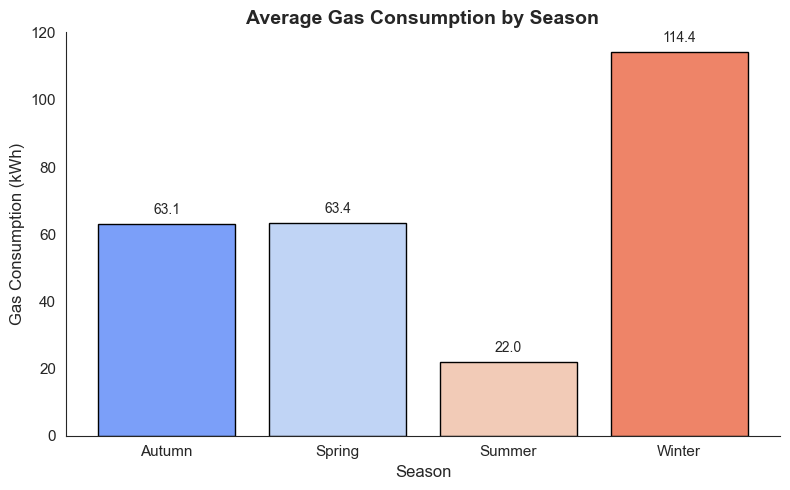

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(seasonal_avg).reset_index()

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
sns.set_style("white")
# Color palette
colors = sns.color_palette("coolwarm", 4)

# Draw bar chart
bars = plt.bar(df['season'], df['gasmeter'], color=colors, edgecolor='black')

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Average Gas Consumption by Season", fontsize=14, fontweight='bold')
plt.ylabel("Gas Consumption (kWh)", fontsize=12)
plt.xlabel("Season", fontsize=12)

# Customize ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove top and right spines for clean look
sns.despine()

# Tight layout for professional spacing
plt.tight_layout()

plt.show()

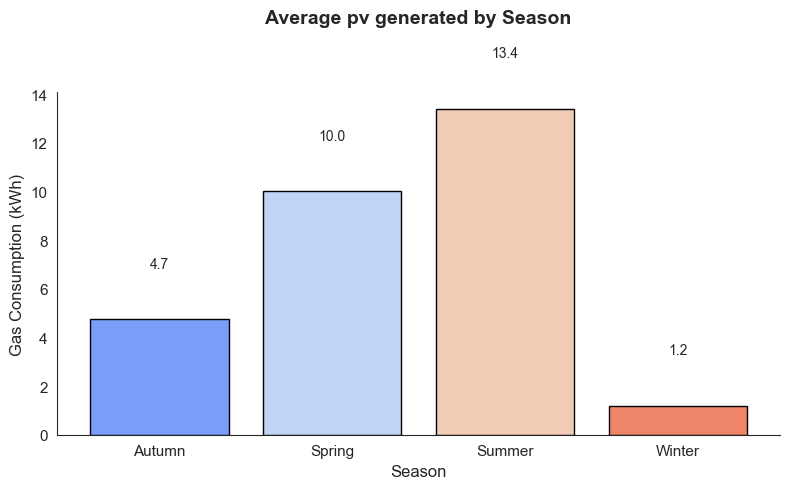

In [21]:
df_pv_hour['month'] = df_pv_hour.index.month
df_pv_hour['season'] = df_pv_hour['month'].apply(get_season)
seasonal_avg = df_pv_hour.groupby('season')['Wert'].mean()

df = pd.DataFrame(seasonal_avg).reset_index()

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
sns.set_style("white")
# Color palette
colors = sns.color_palette("coolwarm", 4)

# Draw bar chart
bars = plt.bar(df['season'], df['Wert'], color=colors, edgecolor='black')

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Average pv generated by Season", fontsize=14, fontweight='bold', pad=50)
plt.ylabel("Gas Consumption (kWh)", fontsize=12)
plt.xlabel("Season", fontsize=12)

# Customize ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove top and right spines for clean look
sns.despine()

# Tight layout for professional spacing
plt.tight_layout()

plt.show()